# 지하철-따릉이 연계수요 분석 프로젝트 오답노트

## 프로젝트 목적

기존 제출본에서는 지하철 하차 인원과 따릉이 이용건수를 결합하여 **지하철 혼잡도와 따릉이 이용량의 관계**를 분석하려고 했다.  
하지만 제출 이후 데이터 단위와 집계 방식에서 문제가 발견되었다.

이 노트북은 기존 분석을 무조건 폐기하는 문서가 아니라, **무엇을 잘못했고, 왜 잘못됐으며, 어떻게 고쳐야 하는지 정리하는 오답노트형 분석 파일**이다.

---

## 핵심 결론

기존 분석의 가장 큰 오류는 **따릉이 데이터와 지하철 데이터의 시간 단위가 일치하지 않은 상태에서 직접 비교했다는 점**이다.

- 따릉이 이용건수: 일자·시간대·대여소 단위의 이용건수
- 지하철 승하차 인원: `사용월` 기준 월 누적 승하차 인원

따라서 기존 분석에서 `따릉이 이용건수 / 지하철 하차인원`을 바로 계산하면,  
**짧은 기간의 따릉이 이용량을 한 달치 지하철 이용량으로 나누는 왜곡**이 발생한다.

본 오답노트에서는 다음을 수행한다.

1. 기존 분석의 문제점 재현
2. 데이터 단위 불일치 확인
3. 지하철 데이터를 일평균 단위로 보정
4. 출퇴근 시간대와 비출퇴근 시간대 비교 방식 수정
5. 수정된 분석 결과를 바탕으로 프로젝트 결론 재정리


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# 한글 폰트 설치
!sudo apt-get -qq -y install fonts-nanum

# 폰트 캐시 갱신
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

# matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
mpl.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

# 0. 분석에서 발견한 오류 목록

| 구분 | 기존 분석에서 한 일 | 문제점 | 수정 방향 |
|---|---|---|---|
| 오류 1 | 따릉이 이용건수와 지하철 월 누적 하차인원을 직접 비교 | 시간 단위가 다름 | 지하철 월 누적값을 일평균으로 변환 |
| 오류 2 | 출퇴근 4시간과 비출퇴근 20시간의 총량 비율을 단순 비교 | 시간 길이가 달라 비출퇴근 비율이 크게 나옴 | 시간당 평균 이용건수로 비교 |
| 오류 3 | 상관계수만 보고 관계를 해석 | 규모가 큰 역이 두 변수 모두 큰 규모 효과 가능 | 피어슨 + 스피어먼 상관계수 함께 확인 |
| 오류 4 | 하차 대비 따릉이 이용비율을 수요 불균형으로 해석 | 이용비율은 수요 지표이지 공급 부족 확정 지표가 아님 | 대여·반납 데이터가 있을 때만 부족 가능성 해석 |
| 오류 5 | 역명 매칭 후 남은 데이터만 분석했지만 매칭률 확인 부족 | 어떤 역이 제외되었는지 설명 부족 | 매칭 전후 역 수와 제외 역 확인 |


In [9]:
# 기본 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# 한글 폰트 설정: Colab/로컬 환경에 따라 작동하지 않을 수 있음
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'NanumGothic'
except:
    pass


# 1. 데이터 불러오기

아래 경로는 기존 프로젝트에서 사용하던 Colab 경로를 기준으로 작성했다.  
실행 환경에 따라 `DATA_PATH`만 수정하면 된다.


In [10]:
# 파일 경로 설정
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"

BIKE_FILE = DATA_PATH + "서울특별시 공공자전거 이용정보(시간대별)_21.06.csv"
SUBWAY_FILE = DATA_PATH + "Seoul_subway_data_20210705.csv"

# 따릉이 데이터 불러오기
bike_use_cols = ["대여일자", "대여시간", "대여소명", "이용건수"]

bike_raw = pd.read_csv(
    BIKE_FILE,
    encoding="cp949",
    usecols=bike_use_cols,
    low_memory=False
)

# 지하철 데이터 불러오기
subway_raw = pd.read_csv(
    SUBWAY_FILE,
    encoding="cp949",
    low_memory=False
)

print("따릉이 데이터 크기:", bike_raw.shape)
print("지하철 데이터 크기:", subway_raw.shape)

display(bike_raw.head())
display(subway_raw.head())


따릉이 데이터 크기: (2616598, 4)
지하철 데이터 크기: (45338, 52)


,대여일자,대여시간,대여소명,이용건수
0,2021-06-01,0,2169. 봉천역 2번출구,1
1,2021-06-01,0,1450. 화랑대역 7번출구,1
2,2021-06-01,0,1282. 송파소방서 맞은편(성내4교),1
3,2021-06-01,0,1288. 문정중교 사거리,1
4,2021-06-01,0,1737. 하나은행 (창동점),1


,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202106,1호선,동대문,715,14,13235,2131,8936,6979,14776,...,8211,16,1434,1,1,0,0,0,0,20210703
1,202106,1호선,동묘앞,51,1,3218,1100,3422,4802,5896,...,2589,4,1348,0,0,0,0,0,0,20210703
2,202106,1호선,서울역,654,17,9008,6400,12474,37203,37253,...,8024,30,637,0,1,0,0,0,0,20210703
3,202106,1호선,시청,37,0,1881,4340,2948,21443,6280,...,1485,3,92,0,0,0,0,0,0,20210703
4,202106,1호선,신설동,343,3,8150,3192,8131,10929,17021,...,5451,10,449,0,0,0,0,0,0,20210703


# 2. 오답 포인트 1: 데이터 기간 단위 확인을 하지 않았다

기존 분석에서는 두 데이터를 바로 병합했다.  
하지만 분석 전에 반드시 다음을 확인해야 한다.

- 따릉이 데이터는 며칠치 데이터인가?
- 지하철 데이터의 `사용월`은 어느 월인가?
- 지하철 승하차 인원은 월 누적인가, 일평균인가?

지하철 데이터의 컬럼이 `04시-05시 승차인원`, `04시-05시 하차인원`처럼 되어 있고 `사용월`이 존재한다면, 일반적으로 **해당 월 누적값**으로 해석해야 한다.


In [11]:
# 따릉이 대여일자 확인
bike_raw["대여일자"] = pd.to_datetime(bike_raw["대여일자"], errors="coerce")

bike_start = bike_raw["대여일자"].min()
bike_end = bike_raw["대여일자"].max()
bike_days = bike_raw["대여일자"].dt.date.nunique()

print("따릉이 시작일:", bike_start)
print("따릉이 종료일:", bike_end)
print("따릉이 데이터 내 고유 일수:", bike_days)

# 지하철 사용월 확인
print("지하철 사용월 목록:")
display(subway_raw["사용월"].value_counts().sort_index())


따릉이 시작일: 2021-06-01 00:00:00
따릉이 종료일: 2021-06-30 00:00:00
따릉이 데이터 내 고유 일수: 30
지하철 사용월 목록:


,count
사용월,
201501,551
201502,550
201503,554
201504,554
201505,556
...,...
202102,605
202103,606
202104,608


## 오답 기록

### 잘못한 점

기존에는 따릉이 데이터의 실제 기간과 지하철 데이터의 집계 기간을 확인하지 않고 바로 병합했다.

### 왜 문제인가?

따릉이 이용건수가 특정 일자 또는 짧은 기간의 값인데, 지하철 하차인원은 한 달 누적값이면 두 값의 단위가 맞지 않는다.  
따라서 `따릉이 이용건수 / 지하철 하차인원`은 실제 환승 수요 비율로 보기 어렵다.

### 수정 방향

두 데이터의 시간 단위를 맞춰야 한다.  
이번 노트북에서는 지하철 월 누적 인원을 30일 기준 일평균으로 변환한다.


# 3. 따릉이 데이터 정제

따릉이 대여소명에는 보통 대여소 번호와 출구 정보가 함께 들어 있다.

예시:

- `2169. 봉천역 2번출구`
- `노원역 1번출구`

이 값에서 지하철역명만 추출한다.


In [12]:
def clean_station_name_from_bike(text):
    # 따릉이 대여소명에서 지하철역명을 추출하여 '역'을 제거한 키를 만든다.
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    text = re.sub(r"^\s*\d+\.\s*", "", text)  # 앞 번호 제거
    text = re.sub(r"\(.*?\)", "", text)          # 괄호 제거
    match = re.search(r"([가-힣A-Za-z0-9]+역)", text)
    if match:
        station = match.group(1)
        station = re.sub(r"역$", "", station)
        return station.strip()
    return np.nan

bike = bike_raw.copy()
bike.columns = bike.columns.str.strip()

bike["대여시간"] = pd.to_numeric(bike["대여시간"], errors="coerce")
bike["이용건수"] = pd.to_numeric(bike["이용건수"], errors="coerce").fillna(0)
bike["역명_정제"] = bike["대여소명"].apply(clean_station_name_from_bike)

bike_station_only = bike[bike["역명_정제"].notna()].copy()

print("전체 따릉이 행 수:", len(bike))
print("역명 추출 성공 행 수:", len(bike_station_only))
print("역명 추출 성공 비율:", round(len(bike_station_only) / len(bike) * 100, 2), "%")

display(bike_station_only.head())


전체 따릉이 행 수: 2616598
역명 추출 성공 행 수: 734413
역명 추출 성공 비율: 28.07 %


,대여일자,대여시간,대여소명,이용건수,역명_정제
0,2021-06-01,0,2169. 봉천역 2번출구,1,봉천
1,2021-06-01,0,1450. 화랑대역 7번출구,1,화랑대
12,2021-06-01,0,1756.서울북부광역등기국,1,서울북부광
16,2021-06-01,0,2186.우리은행 낙성대역지점,1,낙성대
27,2021-06-01,0,1152. 마곡역교차로,1,마곡


# 4. 지하철 데이터 정제

지하철 데이터는 시간대별 승차·하차 컬럼이 가로로 펼쳐져 있다.  
이를 `대여시간`, `역명`, `승차인원`, `하차인원` 형태로 변환한다.


In [13]:
def clean_station_name_from_subway(text):
    # 지하철역명에서 괄호와 '역' 접미사를 제거한다.
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    text = re.sub(r"\(.*?\)", "", text)
    text = re.sub(r"역$", "", text)
    return text.strip()

subway = subway_raw.copy()
subway.columns = subway.columns.str.strip()
subway["역명_정제"] = subway["지하철역"].apply(clean_station_name_from_subway)

# 승하차 컬럼 추출
value_cols = [c for c in subway.columns if "승차인원" in c or "하차인원" in c]
print("승하차 시간대 컬럼 수:", len(value_cols))
print(value_cols[:6])

# melt
subway_melted = pd.melt(
    subway,
    id_vars=["사용월", "호선명", "지하철역", "역명_정제"],
    value_vars=value_cols,
    var_name="시간대_유형",
    value_name="월누적_인원수"
)

# 시간대와 승하차 유형 추출
subway_melted["대여시간"] = subway_melted["시간대_유형"].str.extract(r"(\d+)시-")[0].astype(int)
subway_melted["유형"] = subway_melted["시간대_유형"].apply(lambda x: "승차인원" if "승차" in x else "하차인원")
subway_melted["월누적_인원수"] = pd.to_numeric(subway_melted["월누적_인원수"], errors="coerce").fillna(0)

# 같은 역명이 여러 호선에 존재할 수 있으므로 합산
subway_pivot_month = (
    subway_melted
    .pivot_table(
        index=["대여시간", "역명_정제"],
        columns="유형",
        values="월누적_인원수",
        aggfunc="sum"
    )
    .reset_index()
)
subway_pivot_month.columns.name = None

if "승차인원" not in subway_pivot_month.columns:
    subway_pivot_month["승차인원"] = 0
if "하차인원" not in subway_pivot_month.columns:
    subway_pivot_month["하차인원"] = 0

subway_pivot_month = subway_pivot_month.rename(columns={
    "승차인원": "월누적_승차인원",
    "하차인원": "월누적_하차인원"
})

display(subway_pivot_month.head())


승하차 시간대 컬럼 수: 48
['04시-05시 승차인원', '04시-05시 하차인원', '05시-06시 승차인원', '05시-06시 하차인원', '06시-07시 승차인원', '06시-07시 하차인원']


,대여시간,역명_정제,월누적_승차인원,월누적_하차인원
0,0,4.19민주묘지,4075,25067
1,0,가능,9967,169626
2,0,가락시장,87632,365566
3,0,가산디지털단지,176345,292880
4,0,가양,54737,596326


# 5. 오답 포인트 2: 월 누적 지하철 인원과 따릉이 이용건수를 그대로 병합했다

기존 방식은 아래처럼 병합하는 구조였다.

```python
pd.merge(따릉이_시간대별_이용건수, 지하철_월누적_승하차인원, on=[대여시간, 역명])
```

이 방식은 병합 자체는 가능하지만, 해석이 왜곡된다.

- 따릉이: 분석 기간의 이용건수
- 지하철: 월 누적 승하차인원

따라서 두 데이터를 비교하려면 최소한 지하철 데이터를 일평균으로 변환해야 한다.


In [14]:
# 지하철 데이터를 일평균으로 변환
# 2021년 6월 데이터 기준이면 30일 사용
# 데이터의 사용월이 다른 경우 아래 값을 수정해야 함
SUBWAY_MONTH_DAYS = 30

subway_pivot = subway_pivot_month.copy()
subway_pivot["일평균_승차인원"] = subway_pivot["월누적_승차인원"] / SUBWAY_MONTH_DAYS
subway_pivot["일평균_하차인원"] = subway_pivot["월누적_하차인원"] / SUBWAY_MONTH_DAYS

subway_pivot.head()


,대여시간,역명_정제,월누적_승차인원,월누적_하차인원,일평균_승차인원,일평균_하차인원
0,0,4.19민주묘지,4075,25067,135.833333,835.566667
1,0,가능,9967,169626,332.233333,5654.200000
2,0,가락시장,87632,365566,2921.066667,12185.533333
3,0,가산디지털단지,176345,292880,5878.166667,9762.666667
4,0,가양,54737,596326,1824.566667,19877.533333


# 6. 따릉이도 일평균 기준으로 집계

따릉이 데이터가 실제로 몇 일치인지 확인한 뒤, 역·시간대별 총 이용건수를 일평균으로 변환한다.


In [15]:
# 역명 + 시간대별 따릉이 총 이용건수
bike_hourly_total = (
    bike_station_only
    .groupby(["대여시간", "역명_정제"], as_index=False)["이용건수"]
    .sum()
    .rename(columns={"이용건수": "따릉이_총이용건수"})
)

# 따릉이 데이터 일수로 나누어 일평균 변환
# bike_days가 0이거나 NaN인 경우를 대비
if pd.isna(bike_days) or bike_days == 0:
    bike_days = 1

bike_hourly_total["따릉이_일평균_이용건수"] = bike_hourly_total["따릉이_총이용건수"] / bike_days

bike_hourly_total.head()


,대여시간,역명_정제,따릉이_총이용건수,따릉이_일평균_이용건수
0,0,19민주묘지,50,1.666667
1,0,9호선종합운동장,9,0.300000
2,0,DMC,78,2.600000
3,0,가락시장,73,2.433333
4,0,가양,89,2.966667


# 7. 수정된 방식으로 데이터 병합

이제 `대여시간 + 역명_정제` 기준으로 병합하되, 분석에는 일평균 컬럼을 사용한다.


In [16]:
df_corrected = pd.merge(
    bike_hourly_total,
    subway_pivot,
    on=["대여시간", "역명_정제"],
    how="inner"
)

# 컬럼 정리
df_corrected = df_corrected[[
    "대여시간", "역명_정제",
    "따릉이_총이용건수", "따릉이_일평균_이용건수",
    "월누적_승차인원", "월누적_하차인원",
    "일평균_승차인원", "일평균_하차인원"
]].copy()

df_corrected = df_corrected.rename(columns={"역명_정제": "지하철"})

print("수정 후 병합 데이터 크기:", df_corrected.shape)
display(df_corrected.head())


수정 후 병합 데이터 크기: (6262, 8)


,대여시간,지하철,따릉이_총이용건수,따릉이_일평균_이용건수,월누적_승차인원,월누적_하차인원,일평균_승차인원,일평균_하차인원
0,0,가락시장,73,2.433333,87632,365566,2921.066667,12185.533333
1,0,가양,89,2.966667,54737,596326,1824.566667,19877.533333
2,0,가오리,28,0.933333,4201,37987,140.033333,1266.233333
3,0,가좌,38,1.266667,2895,65208,96.500000,2173.600000
4,0,강남구청,9,0.300000,130947,223596,4364.900000,7453.200000


# 8. 매칭률 확인

기존 분석에서 부족했던 부분은 `inner merge` 후 어떤 역이 남고 어떤 역이 제외됐는지를 확인하지 않았다는 점이다.  
분석 대상이 되는 역이 전체 중 어느 정도인지 확인해야 한다.


In [17]:
bike_station_set = set(bike_hourly_total["역명_정제"].dropna().unique())
subway_station_set = set(subway_pivot["역명_정제"].dropna().unique())
matched_station_set = bike_station_set & subway_station_set

print("따릉이 역명 추출 역 수:", len(bike_station_set))
print("지하철 역 수:", len(subway_station_set))
print("매칭된 역 수:", len(matched_station_set))
print("따릉이 기준 매칭률:", round(len(matched_station_set) / len(bike_station_set) * 100, 2), "%")
print("지하철 기준 매칭률:", round(len(matched_station_set) / len(subway_station_set) * 100, 2), "%")

# 따릉이에는 있는데 지하철에는 매칭되지 않은 이름 예시
unmatched_bike = sorted(list(bike_station_set - subway_station_set))[:20]
print("따릉이 추출 역명 중 지하철 데이터와 매칭되지 않은 예시:")
print(unmatched_bike)


따릉이 역명 추출 역 수: 286
지하철 역 수: 525
매칭된 역 수: 263
따릉이 기준 매칭률: 91.96 %
지하철 기준 매칭률: 50.1 %
따릉이 추출 역명 중 지하철 데이터와 매칭되지 않은 예시:
['19민주묘지', '9호선종합운동장', 'DMC', '개화광', '대한무', '도봉산광', '둔촌', '매헌', '서소문', '서소문성지', '서울북부광', '송파지', '시민의숲', '시티', '양재시민의숲', '우이', '유원지', '은평', '입구', '제기']


# 9. 오답 포인트 3: 출퇴근 시간대와 비출퇴근 시간대의 총량 비율을 단순 비교했다

기존 그래프에서는 다음과 같은 결과가 나왔다.

- 비출퇴근 시간대: 약 70%
- 출퇴근 시간대: 약 30%

하지만 이 비교는 공정하지 않다.

출퇴근 시간대는 보통 4시간이다.

- 출근: 07시, 08시
- 퇴근: 18시, 19시

비출퇴근 시간대는 나머지 20시간이다.  
따라서 4시간과 20시간의 총량 비율을 단순 비교하면 비출퇴근 시간대가 더 크게 보일 수밖에 없다.

수정 방향은 **시간당 일평균 이용건수**로 비교하는 것이다.


In [18]:
# 시간대 구분
COMMUTE_HOURS = [7, 8, 18, 19]
EVENING_HOURS = [17, 18, 19]  # 재검증용 퇴근 시간대 후보

df = df_corrected.copy()


In [19]:
df["시간대구분"] = df["대여시간"].apply(lambda x: "출퇴근 시간대" if x in COMMUTE_HOURS else "비출퇴근 시간대")

# 총량 기준 비율
usage_share = (
    df.groupby("시간대구분", as_index=False)["따릉이_일평균_이용건수"]
    .sum()
    .rename(columns={"따릉이_일평균_이용건수": "일평균_총이용건수"})
)
usage_share["총량비율_%"] = usage_share["일평균_총이용건수"] / usage_share["일평균_총이용건수"].sum() * 100

# 시간 길이 반영
hours_table = pd.DataFrame({
    "시간대구분": ["출퇴근 시간대", "비출퇴근 시간대"],
    "시간수": [len(COMMUTE_HOURS), 24 - len(COMMUTE_HOURS)]
})

usage_share = usage_share.merge(hours_table, on="시간대구분", how="left")
usage_share["시간당_일평균_이용건수"] = usage_share["일평균_총이용건수"] / usage_share["시간수"]

usage_share


,시간대구분,일평균_총이용건수,총량비율_%,시간수,시간당_일평균_이용건수
0,비출퇴근 시간대,19470.366667,70.355747,20,973.518333
1,출퇴근 시간대,8203.800000,29.644253,4,2050.950000


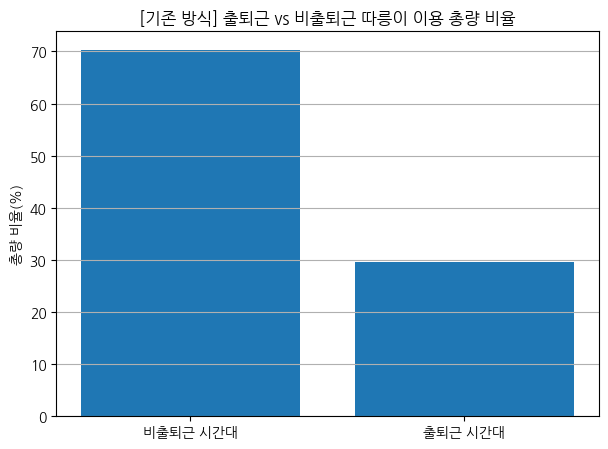

In [20]:
# 그래프 1: 기존 방식의 총량 비율
plt.figure(figsize=(7, 5))
plt.bar(usage_share["시간대구분"], usage_share["총량비율_%"])
plt.ylabel("총량 비율(%)")
plt.title("[기존 방식] 출퇴근 vs 비출퇴근 따릉이 이용 총량 비율")
plt.grid(axis="y")
plt.show()


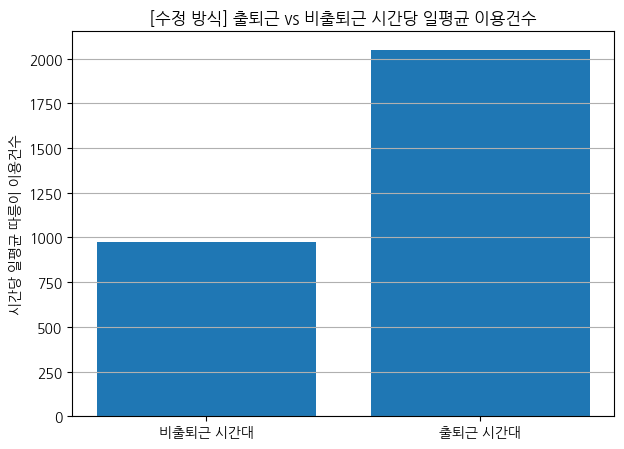

In [21]:
# 그래프 2: 수정 방식의 시간당 일평균 이용건수
plt.figure(figsize=(7, 5))
plt.bar(usage_share["시간대구분"], usage_share["시간당_일평균_이용건수"])
plt.ylabel("시간당 일평균 따릉이 이용건수")
plt.title("[수정 방식] 출퇴근 vs 비출퇴근 시간당 일평균 이용건수")
plt.grid(axis="y")
plt.show()


## 오답 기록

### 잘못한 점

출퇴근 4시간과 비출퇴근 20시간의 따릉이 이용 총량을 그대로 비교했다.

### 왜 문제인가?

비출퇴근 시간대가 시간 길이 자체가 훨씬 길기 때문에 총량 기준으로는 당연히 크게 나타날 수 있다.

### 수정 방향

출퇴근과 비출퇴근을 비교할 때는 **시간당 평균 이용건수**로 보정해야 한다.


# 10. 상관관계 재검증

기존 분석에서는 전체 시간대 또는 월 누적 하차인원을 그대로 사용하여 상관관계를 계산했다.  
이번에는 일평균 기준으로 다음을 비교한다.

1. 출근 시간대
2. 퇴근 시간대
3. 출퇴근 시간대 전체
4. 비출퇴근 시간대

또한 피어슨 상관계수와 스피어먼 상관계수를 함께 확인한다.

- 피어슨: 두 변수의 선형 관계
- 스피어먼: 순위 기반 관계, 극단값에 상대적으로 덜 민감


In [22]:
def corr_pair(data, x_col, y_col):
    temp = data[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(temp) < 2:
        return np.nan, np.nan, len(temp)
    pearson = temp[x_col].corr(temp[y_col], method="pearson")
    spearman = temp[x_col].corr(temp[y_col], method="spearman")
    return pearson, spearman, len(temp)

analysis_groups = {
    "출근 시간대(07-08시)": df[df["대여시간"].isin([7, 8])],
    "퇴근 시간대(18-19시)": df[df["대여시간"].isin([18, 19])],
    "퇴근 시간대 후보(17-19시)": df[df["대여시간"].isin([17, 18, 19])],
    "출퇴근 시간대(07-08,18-19시)": df[df["대여시간"].isin(COMMUTE_HOURS)],
    "비출퇴근 시간대": df[~df["대여시간"].isin(COMMUTE_HOURS)],
    "전체 시간대": df
}

corr_rows = []
for name, data in analysis_groups.items():
    pearson, spearman, n = corr_pair(data, "일평균_하차인원", "따릉이_일평균_이용건수")
    corr_rows.append({
        "구분": name,
        "표본수": n,
        "피어슨상관계수": pearson,
        "스피어먼상관계수": spearman
    })

corr_summary = pd.DataFrame(corr_rows)
corr_summary


,구분,표본수,피어슨상관계수,스피어먼상관계수
0,출근 시간대(07-08시),524,0.171761,0.246282
1,퇴근 시간대(18-19시),526,0.395692,0.498635
2,퇴근 시간대 후보(17-19시),789,0.408941,0.495310
3,"출퇴근 시간대(07-08,18-19시)",1050,0.269615,0.396070
4,비출퇴근 시간대,5212,0.428512,0.664407
5,전체 시간대,6262,0.408159,0.651186


## 해석 기준

상관계수는 일반적으로 다음처럼 해석할 수 있다.

| 상관계수 절댓값 | 해석 |
|---:|---|
| 0.0 ~ 0.2 | 거의 관계 없음 또는 매우 약함 |
| 0.2 ~ 0.4 | 약한 관계 |
| 0.4 ~ 0.6 | 중간 정도 관계 |
| 0.6 이상 | 강한 관계 |

단, 상관계수는 인과관계를 의미하지 않는다.  
따라서 `하차인원이 많아서 따릉이 이용이 증가한다`고 단정하면 안 되고,  
`두 변수 사이에 함께 증가하는 경향이 있다` 정도로 해석해야 한다.


# 11. 퇴근 시간대 산점도 재작성

기존 그래프의 X축이 월 누적 하차인원이었다면, 수정 그래프에서는 `일평균 하차인원`을 사용한다.  
이렇게 해야 축 단위가 현실적으로 보이고, 발표 중 방어가 가능하다.


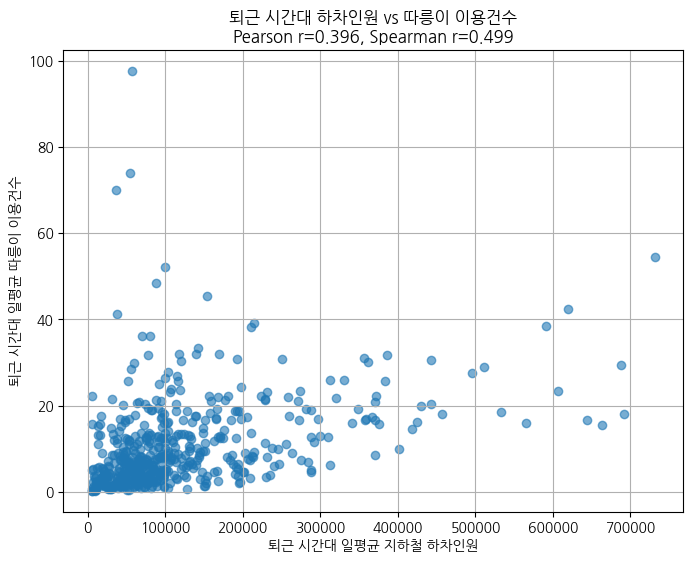

In [23]:
df_evening = df[df["대여시간"].isin([18, 19])].copy()

evening_pearson, evening_spearman, evening_n = corr_pair(
    df_evening,
    "일평균_하차인원",
    "따릉이_일평균_이용건수"
)

plt.figure(figsize=(8, 6))

plt.scatter(
    df_evening["일평균_하차인원"],
    df_evening["따릉이_일평균_이용건수"],
    alpha=0.6
)

plt.xlabel("퇴근 시간대 일평균 지하철 하차인원")
plt.ylabel("퇴근 시간대 일평균 따릉이 이용건수")

plt.title(
    f"퇴근 시간대 하차인원 vs 따릉이 이용건수\n"
    f"Pearson r={evening_pearson:.3f}, Spearman r={evening_spearman:.3f}"
)

plt.grid(True)
plt.show()

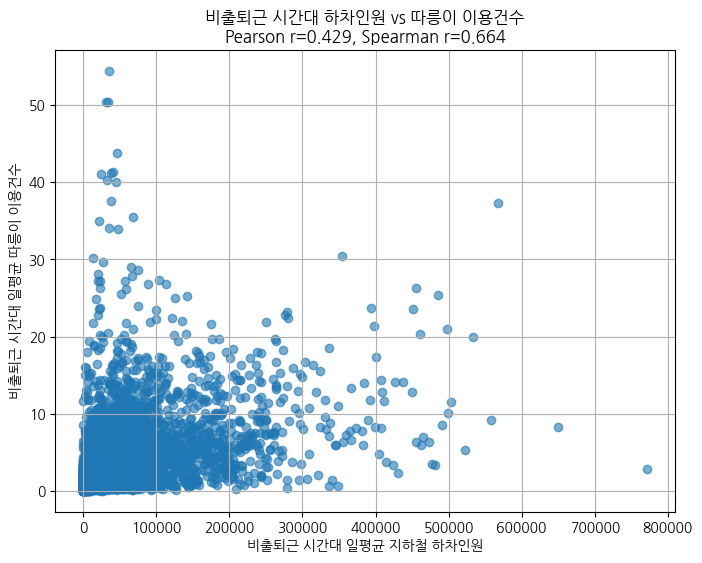

In [24]:
df_non_commute = df[~df["대여시간"].isin(COMMUTE_HOURS)].copy()

non_pearson, non_spearman, non_n = corr_pair(
    df_non_commute,
    "일평균_하차인원",
    "따릉이_일평균_이용건수"
)

plt.figure(figsize=(8, 6))

plt.scatter(
    df_non_commute["일평균_하차인원"],
    df_non_commute["따릉이_일평균_이용건수"],
    alpha=0.6
)

plt.xlabel("비출퇴근 시간대 일평균 지하철 하차인원")
plt.ylabel("비출퇴근 시간대 일평균 따릉이 이용건수")

plt.title(
    f"비출퇴근 시간대 하차인원 vs 따릉이 이용건수\n"
    f"Pearson r={non_pearson:.3f}, Spearman r={non_spearman:.3f}"
)

plt.grid(True)
plt.show()


# 12. 하차 대비 따릉이 이용비율 재계산

이 비율은 반드시 일평균 기준으로 계산한다.

```text
하차 대비 따릉이 이용비율 = 따릉이 일평균 이용건수 / 지하철 일평균 하차인원
```

주의할 점은 이 값은 **수요 집중도 지표**이지, 자전거 부족을 직접 증명하는 지표는 아니다.


In [25]:
import numpy as np
import pandas as pd

# 원본 df 보호
df_ratio = df.copy()

# 숫자형 변환
df_ratio["따릉이_일평균_이용건수"] = pd.to_numeric(
    df_ratio["따릉이_일평균_이용건수"],
    errors="coerce"
)

df_ratio["일평균_하차인원"] = pd.to_numeric(
    df_ratio["일평균_하차인원"],
    errors="coerce"
)

# 하차 대비 따릉이 이용비율 계산
df_ratio["하차대비_따릉이이용비율"] = (
    df_ratio["따릉이_일평균_이용건수"] / df_ratio["일평균_하차인원"]
)

df_ratio["하차대비_따릉이이용비율_%"] = (
    df_ratio["하차대비_따릉이이용비율"] * 100
)

# inf, NaN 처리
df_ratio = df_ratio.replace([np.inf, -np.inf], np.nan).fillna(0)

# 출퇴근 시간대 역별 합산
commute_station = (
    df_ratio[df_ratio["대여시간"].isin(COMMUTE_HOURS)]
    .groupby("지하철", as_index=False)
    .agg({
        "따릉이_일평균_이용건수": "sum",
        "일평균_하차인원": "sum"
    })
)

# 역별 출퇴근 시간대 하차 대비 따릉이 이용비율 재계산
commute_station["하차대비_따릉이이용비율_%"] = (
    commute_station["따릉이_일평균_이용건수"]
    / commute_station["일평균_하차인원"]
    * 100
)

commute_station = commute_station.replace([np.inf, -np.inf], np.nan).fillna(0)

# 비율 높은 역 Top 10
top_ratio = commute_station.sort_values(
    "하차대비_따릉이이용비율_%",
    ascending=False
).head(10)

top_ratio

,지하철,따릉이_일평균_이용건수,일평균_하차인원,하차대비_따릉이이용비율_%
251,한성백제,54.233333,17706.933333,0.306283
78,마곡나루,287.166667,238513.266667,0.120399
77,마곡,169.366667,146717.700000,0.115437
135,석촌고분,53.100000,46452.800000,0.114310
211,응봉,43.666667,39735.866667,0.109892
144,송파나루,41.566667,40045.800000,0.103798
160,신목동,56.000000,85230.000000,0.065705
61,도림천,22.600000,40489.033333,0.055818
44,노들,42.766667,91404.200000,0.046789
76,뚝섬유원지,95.066667,203706.266667,0.046669


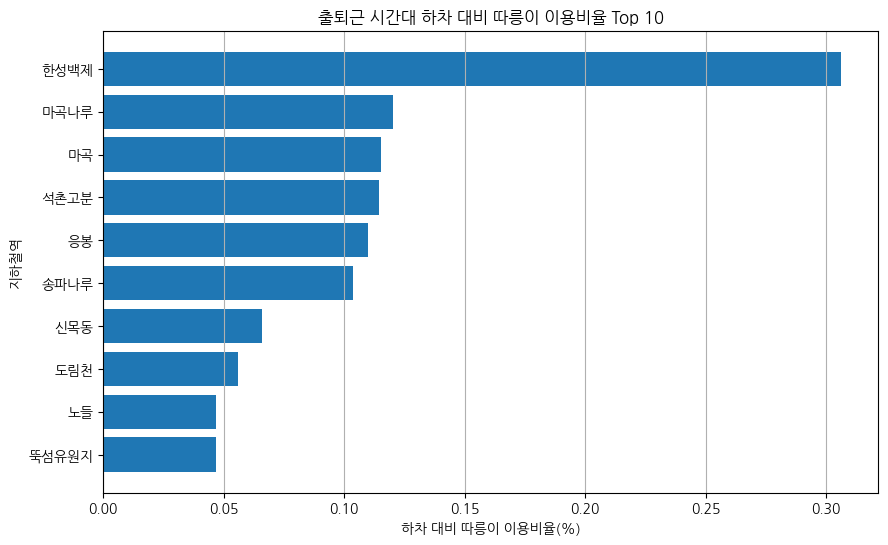

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_ratio["지하철"],
    top_ratio["하차대비_따릉이이용비율_%"]
)

plt.xlabel("하차 대비 따릉이 이용비율(%)")
plt.ylabel("지하철역")
plt.title("출퇴근 시간대 하차 대비 따릉이 이용비율 Top 10")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()


# 13. 수정된 결론

## 기존 결론의 문제

기존 결론은 `지하철 하차 인원이 많은 역에서 따릉이 이용도 증가한다`는 방향으로 작성되었다.  
하지만 데이터 단위가 맞지 않았기 때문에 이 결론은 과장될 위험이 있었다.

## 수정된 결론

본 프로젝트의 결론은 다음처럼 수정하는 것이 더 안전하다.

> 지하철 하차 인원과 따릉이 이용건수 사이에는 일부 양의 관계가 관찰될 수 있으나, 기존 분석은 월 누적 지하철 인원과 따릉이 이용건수를 직접 비교해 단위 불일치 문제가 있었다. 따라서 지하철 데이터를 일평균 기준으로 보정한 뒤 출퇴근 시간대와 비출퇴근 시간대를 재비교해야 한다. 수정 분석에서는 하차 대비 따릉이 이용비율을 수요 집중도 지표로 사용하되, 이를 자전거 부족의 직접 증거로 해석하지 않고 재배치 검토 후보를 선별하는 보조 지표로 해석한다.


# 14. 오답노트 최종 정리

## 잘못한 것 1: 데이터 기간 단위를 확인하지 않았다

- 따릉이와 지하철 데이터의 집계 기간이 다를 수 있는데 바로 병합했다.
- 지하철 데이터는 월 누적값인데, 따릉이 이용건수와 직접 비교했다.

## 잘못한 것 2: 월 누적 지하철 인원을 X축으로 사용했다

- 그래프상으로는 우상향처럼 보일 수 있으나, 실제로는 규모가 큰 역이 두 값 모두 큰 **규모 효과**일 수 있다.
- 수정 후에는 `일평균 하차인원`을 사용해야 한다.

## 잘못한 것 3: 출퇴근과 비출퇴근을 총량 비율로 비교했다

- 출퇴근은 4시간, 비출퇴근은 20시간이므로 총량 비교는 불공정하다.
- `시간당 일평균 이용건수`로 보정해야 한다.

## 잘못한 것 4: 이용비율을 공급 부족으로 과도하게 해석했다

- 하차 대비 따릉이 이용비율은 수요 집중도를 보여준다.
- 자전거 부족이나 거치대 부족은 대여·반납 재고 데이터가 있어야 더 강하게 말할 수 있다.

## 잘못한 것 5: 병합 결과 검증이 부족했다

- `inner merge` 후 남은 역 수와 제외된 역을 확인해야 한다.
- 역명 정제 과정에서 매칭 오류가 생길 수 있으므로 매칭률을 반드시 확인해야 한다.


In [27]:
# 최종 결과 저장
output_path = "오답노트_수정분석_지하철_따릉이_연계수요.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("저장 완료:", output_path)


저장 완료: 오답노트_수정분석_지하철_따릉이_연계수요.csv


# 15. 발표/보고서에 넣을 수 있는 반성 문장

> 기존 분석에서는 따릉이 이용건수와 지하철 하차인원을 결합하는 과정에서 두 데이터의 시간 단위가 일치하는지 충분히 검증하지 못했다. 그 결과 특정 기간의 따릉이 이용량과 월 누적 지하철 승하차 인원이 직접 비교되는 문제가 발생했다. 본 오답노트에서는 해당 오류를 확인하고, 지하철 데이터를 일평균 기준으로 변환하여 분석 단위를 보정하였다. 또한 출퇴근 시간대와 비출퇴근 시간대 비교에서도 시간 구간 길이가 다르다는 점을 반영하여 시간당 평균 이용건수 기준으로 재해석하였다. 이를 통해 기존 분석의 한계를 명확히 인식하고, 데이터 분석에서 단위 검증과 집계 기준 확인이 필수적임을 확인하였다.
